In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
data=pd.read_csv('/kaggle/input/titanic/train.csv')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
data.drop(columns = ['PassengerId','Ticket','Cabin','Name'],inplace = True)
data


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


<AxesSubplot:>

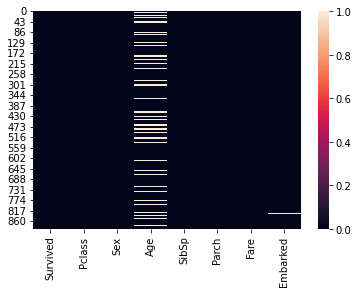

In [4]:
import seaborn as sns
sns.heatmap(data.isnull())

In [5]:
data.Age = data.Age.fillna(0)


In [6]:
data.Embarked = data.Embarked.fillna(0)
data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [7]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [8]:
data['Sex'] = data['Sex'].map({'female':1,'male':0}).astype(int)
data['Embarked_S'] = data['Embarked'].replace('Q',0).replace('C',0).replace('S',1)
data['Embarked_Q'] = data['Embarked'].replace('C',0).replace('S',0).replace('Q',1)
data['Embarked_C'] = data['Embarked'].replace('S',0).replace('Q',0).replace('C',1)

In [9]:
data.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Embarked_S,Embarked_Q,Embarked_C
0,0,3,0,22.0,1,0,7.2500,S,1,0,0
1,1,1,1,38.0,1,0,71.2833,C,0,0,1
2,1,3,1,26.0,0,0,7.9250,S,1,0,0
3,1,1,1,35.0,1,0,53.1000,S,1,0,0
4,0,3,0,35.0,0,0,8.0500,S,1,0,0


In [10]:
data.drop(columns = ['Embarked'],inplace = True)


1.which gender survived more malae or female?



In [11]:
data[(data.Survived ==1)].groupby('Sex').count().iloc[:1,0]


Sex
0    109
Name: Survived, dtype: int64

In [12]:
x = data.iloc[:,0:8]
y = data['Survived']

In [13]:
x = data.drop(columns = ['Survived'])


In [14]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_S,Embarked_Q,Embarked_C
0,3,0,22.0,1,0,7.2500,1,0,0
1,1,1,38.0,1,0,71.2833,0,0,1
2,3,1,26.0,0,0,7.9250,1,0,0
3,1,1,35.0,1,0,53.1000,1,0,0
4,3,0,35.0,0,0,8.0500,1,0,0
...,...,...,...,...,...,...,...,...,...
886,2,0,27.0,0,0,13.0000,1,0,0
887,1,1,19.0,0,0,30.0000,1,0,0
888,3,1,0.0,1,2,23.4500,1,0,0
889,1,0,26.0,0,0,30.0000,0,0,1


In [15]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [16]:
x.dtypes


Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_S      int64
Embarked_Q      int64
Embarked_C      int64
dtype: object

In [17]:
nominal_col = [1]
ordinal_col = []
numeric_col = [0,3,4,6,7,8]
KBin_col = [5]
Bina_col = [2]
#null_col = []


In [18]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.preprocessing import KBinsDiscretizer,Binarizer
#from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn import set_config
trans  = make_column_transformer((OneHotEncoder(sparse = False),nominal_col),
                                  (OrdinalEncoder(),ordinal_col),
                                 (KBinsDiscretizer(),KBin_col),
                                 (Binarizer(threshold = 55),Bina_col),
                                 #(SimpleImputer(strategy = 'mean'),null_col),
                                 remainder = 'passthrough')
set_config(display = 'diagram')
trans

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder', OneHotEncoder(sparse=False),
                                 [1]),
                                ('ordinalencoder', OrdinalEncoder(), []),
                                ('kbinsdiscretizer', KBinsDiscretizer(), [5]),
                                ('binarizer', Binarizer(threshold=55), [2])])

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.34)  

In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
model = KNeighborsClassifier(9)
pipe = make_pipeline(trans,model)

In [21]:
model


KNeighborsClassifier(n_neighbors=9)

In [22]:
pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [1]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('kbinsdiscretizer',
                                                  KBinsDiscretizer(), [5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [2])])),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=9))])

In [23]:
pipe.fit(x_train,y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [1]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('kbinsdiscretizer',
                                                  KBinsDiscretizer(), [5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [2])])),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=9))])

In [24]:
pred = pipe.predict(x_test)


In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(pred,y_test)*100

76.89768976897689

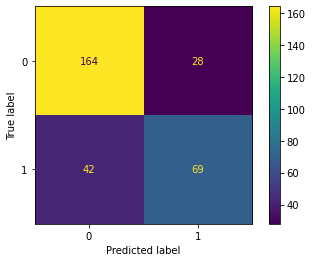

In [26]:
from sklearn.metrics import plot_confusion_matrix
plot_confusion_matrix(pipe,x_test,y_test)

In [27]:
# from sklearn.svm import SVC
# from sklearn.pipeline import make_pipeline
# model_n =SVC(kernel='linear')
# pipe_n = make_pipeline(trans,model_n)
# pipe_n.fit(x_train,y_train)
# pred_n = pipe_n.predict(x_test)
# accuracy_score(pred_n,y_test)*100

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
model_2 = LogisticRegression(solver = 'liblinear')
pipe_2 = make_pipeline(trans,model_2)

In [29]:
model_2


LogisticRegression(solver='liblinear')

In [30]:
pipe_2

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [1]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('kbinsdiscretizer',
                                                  KBinsDiscretizer(), [5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [2])])),
                ('logisticregression', LogisticRegression(solver='liblinear'))])

In [31]:
pipe_2.fit(x_train,y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [1]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('kbinsdiscretizer',
                                                  KBinsDiscretizer(), [5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [2])])),
                ('logisticregression', LogisticRegression(solver='liblinear'))])

In [32]:
test_data = pd.read_csv('/kaggle/input/titanic/test.csv')
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [33]:
test_data = test_data.drop(columns = ['PassengerId','Name','Ticket','Cabin'])

In [34]:
test_data.isnull().sum()


Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

In [35]:
test_data.dtypes


Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

In [36]:
test_data['Sex'] = test_data['Sex'].map({'female':1,'male':0}).astype(int)
test_data['Embarked_S'] = test_data['Embarked'].replace('Q',0).replace('C',0).replace('S',1)
test_data['Embarked_Q'] = test_data['Embarked'].replace('C',0).replace('S',0).replace('Q',1)
test_data['Embarked_C'] = test_data['Embarked'].replace('S',0).replace('Q',0).replace('C',1)

In [37]:
test_data.Age = test_data.Age.fillna(0)
test_data.Fare = test_data.Fare.fillna(0)

In [38]:
test_data


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Embarked_S,Embarked_Q,Embarked_C
0,3,0,34.5,0,0,7.8292,Q,0,1,0
1,3,1,47.0,1,0,7.0000,S,1,0,0
2,2,0,62.0,0,0,9.6875,Q,0,1,0
3,3,0,27.0,0,0,8.6625,S,1,0,0
4,3,1,22.0,1,1,12.2875,S,1,0,0
...,...,...,...,...,...,...,...,...,...,...
413,3,0,0.0,0,0,8.0500,S,1,0,0
414,1,1,39.0,0,0,108.9000,C,0,0,1
415,3,0,38.5,0,0,7.2500,S,1,0,0
416,3,0,0.0,0,0,8.0500,S,1,0,0


In [39]:
test_data.drop(columns = ['Embarked'],inplace = True)


In [40]:
test_data.dtypes


Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_S      int64
Embarked_Q      int64
Embarked_C      int64
dtype: object

In [41]:
submission_data = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [42]:
submission_data.drop(columns = ['PassengerId'],inplace = True)
submission_data

,Survived
0,0
1,1
2,0
3,0
4,1
...,...
413,0
414,1
415,0
416,0


In [43]:
#Here model_2 is LogesticRegression
model_2.fit(x_train,y_train)

LogisticRegression(solver='liblinear')

In [44]:
from sklearn.metrics import accuracy_score
model_2.score(x_train,y_train)*100

80.27210884353741

In [45]:
prediction_model_2 = model_2.predict(test_data)


In [46]:
accuracy_score(prediction_model_2,submission_data)*100


93.54066985645933

In [47]:
print("Train Accuracy: {:.5f}%".format(model_2.score(x_train,y_train)*100))
print('Test Accuracy: {:.5f}%'.format(accuracy_score(prediction_model_2,submission_data)*100))

Train Accuracy: 80.27211%
Test Accuracy: 93.54067%


In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
model_3 = DecisionTreeClassifier()
pipe_3 = make_pipeline(trans,model_3)

In [49]:
model_3

DecisionTreeClassifier()

In [50]:
pipe_3

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [1]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('kbinsdiscretizer',
                                                  KBinsDiscretizer(), [5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [2])])),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

In [51]:
pipe_3.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [1]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('kbinsdiscretizer',
                                                  KBinsDiscretizer(), [5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [2])])),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

In [52]:
from sklearn.metrics import accuracy_score
pipe_3.score(x_train,y_train)*100

87.58503401360545

In [53]:
prediction_model_3 = pipe_3.predict(test_data)

In [54]:
prediction_model_3

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,

In [55]:
accuracy_score(prediction_model_3,submission_data)*100

87.08133971291866

In [56]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier

l1 = KNeighborsClassifier(9)
l2 = LogisticRegression()
l3= DecisionTreeClassifier()
model_4 = VotingClassifier(estimators=[('x1',model),('x2',model_2),('x3',model_3)],voting='soft',verbose=True)
model_4


VotingClassifier(estimators=[('x1', KNeighborsClassifier(n_neighbors=9)),
                             ('x2', LogisticRegression(solver='liblinear')),
                             ('x3', DecisionTreeClassifier())],
                 verbose=True, voting='soft')

In [57]:
from sklearn.pipeline import make_pipeline
pipe_4 = make_pipeline(trans,model_4)                          
pipe_4.fit(x_train,y_train)
#print(pipe_4.predict(test_data))

[Voting] ....................... (1 of 3) Processing x1, total=   0.0s
[Voting] ....................... (2 of 3) Processing x2, total=   0.0s
[Voting] ....................... (3 of 3) Processing x3, total=   0.0s


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [1]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('kbinsdiscretizer',
                                                  KBinsDiscretizer(), [5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [2])])),
                ('votingclassifier',
                 VotingClassifier(estimators=[('x1',
                                               KNeighborsClassifier(n_neighbors=9)),
                                              ('x2',
                                               LogisticRegression(solver='liblinear')),
                                              ('x3', DecisionTreeClassifier())],
                                  verbose=True, voting='soft'))])

In [58]:
pipe_4.predict(test_data)

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,

In [59]:
from sklearn.metrics import accuracy_score
pipe_4.score(x_train,y_train)*100

86.56462585034014

In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

l1 = KNeighborsClassifier(9)
l2 = LogisticRegression()
l3= DecisionTreeClassifier()
model_5 = BaggingClassifier(verbose=True)
model_5

BaggingClassifier(verbose=True)

In [61]:
from sklearn.pipeline import make_pipeline
pipe_5 = make_pipeline(trans,model_5)                          
pipe_5.fit(x_train,y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [1]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('kbinsdiscretizer',
                                                  KBinsDiscretizer(), [5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [2])])),
                ('baggingclassifier', BaggingClassifier(verbose=True))])

In [62]:
pipe_5.predict(test_data)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,

In [63]:
from sklearn.metrics import accuracy_score
pipe_5.score(x_train,y_train)*100

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


87.58503401360545

In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier 

params = {'criterion':['gini','entropy'],'max_depth':[None,2,5,10],'min_samples_split':[2,10,100]}

q_pipe = make_pipeline (trans,GridSearchCV (model_3 ,params,verbose=3,refit=True))
                    
q_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [1]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('kbinsdiscretizer',
                                                  KBinsDiscretizer(), [5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [2])])),
                ('gridsearchcv',
                 GridSearchCV(estimator=DecisionTreeClassifier(),
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [None, 2, 5, 10],
                                          'min_samples_split': [2, 10, 100]},
                              verbose=3))])

In [65]:
DecisionTreeClassifier().get_params().keys()


dict_keys(['ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_impurity_split', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'presort', 'random_state', 'splitter'])

In [66]:
q_pipe.fit(x_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] criterion=gini, max_depth=None, min_samples_split=2 .............
[CV]  criterion=gini, max_depth=None, min_samples_split=2, score=0.839, total=   0.0s
[CV] criterion=gini, max_depth=None, min_samples_split=2 .............
[CV]  criterion=gini, max_depth=None, min_samples_split=2, score=0.805, total=   0.0s
[CV] criterion=gini, max_depth=None, min_samples_split=2 .............
[CV]  criterion=gini, max_depth=None, min_samples_split=2, score=0.763, total=   0.0s
[CV] criterion=gini, max_depth=None, min_samples_split=2 .............
[CV]  criterion=gini, max_depth=None, min_samples_split=2, score=0.812, total=   0.0s
[CV] criterion=gini, max_depth=None, min_samples_split=2 .............
[CV]  criterion=gini, max_depth=None, min_samples_split=2, score=0.821, total=   0.0s
[CV] criterion=gini, max_depth=None, min_samples_split=10 ............
[CV]  criterion=gini, max_depth=None, min_samples_split=10, score=0.847, total=   

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s


[CV]  criterion=entropy, max_depth=2, min_samples_split=10, score=0.729, total=   0.0s
[CV] criterion=entropy, max_depth=2, min_samples_split=10 ............
[CV]  criterion=entropy, max_depth=2, min_samples_split=10, score=0.778, total=   0.0s
[CV] criterion=entropy, max_depth=2, min_samples_split=10 ............
[CV]  criterion=entropy, max_depth=2, min_samples_split=10, score=0.795, total=   0.0s
[CV] criterion=entropy, max_depth=2, min_samples_split=100 ...........
[CV]  criterion=entropy, max_depth=2, min_samples_split=100, score=0.822, total=   0.0s
[CV] criterion=entropy, max_depth=2, min_samples_split=100 ...........
[CV]  criterion=entropy, max_depth=2, min_samples_split=100, score=0.763, total=   0.0s
[CV] criterion=entropy, max_depth=2, min_samples_split=100 ...........
[CV]  criterion=entropy, max_depth=2, min_samples_split=100, score=0.729, total=   0.0s
[CV] criterion=entropy, max_depth=2, min_samples_split=100 ...........
[CV]  criterion=entropy, max_depth=2, min_samples

[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    0.3s finished


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  [1]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('kbinsdiscretizer',
                                                  KBinsDiscretizer(), [5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [2])])),
                ('gridsearchcv',
                 GridSearchCV(estimator=DecisionTreeClassifier(),
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': [None, 2, 5, 10],
                                          'min_samples_split': [2, 10, 100]},
                              verbose=3))])

In [67]:
q_pipe.predict(test_data)

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,

In [68]:
from sklearn.metrics import accuracy_score
q_pipe.score(x_train,y_train)*100

87.58503401360545

In [69]:
q_pipe.named_steps['gridsearchcv'].best_params_

{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}